# 💳 Project #07: Credit Card User Segmentation Engine
## 📊 Category: 2-Unsupervised-Learning (Behavioral Clustering Series)

**Status:** Completed ✅ | **Performance:** 0.3982 Silhouette Coefficient 🚀

### 🎯 Industrial Objective
The **Credit Card Segmentation Engine** is an autonomous clustering system designed within the **Vuxora Financial Engine** ecosystem. It groups cardholders based on 18 behavioral dimensions to drive precision-targeted credit offerings and risk management.

---

### 🧠 The 10-Step Engineering Pipeline (Refined Sequence)
Strictly adhering to the **Architecting-Intelligence** core framework:

1.  **Objective Definition:** Automating segment discovery for 9,000 active users.
2.  **Data Ingestion:** Extracting `Credit Card.csv` from `/content/clustering.zip`.
3.  **Data Manipulation:** Dropping non-predictive `CUST_ID` to reduce noise.
4.  **Advanced Feature Engineering:** Creating **'MONTHLY_AVG_PURCHASE'** to capture long-term intent.
5.  **Industrial Data Cleaning:** Executing **Median Imputation** for `MINIMUM_PAYMENTS` and `CREDIT_LIMIT`.
6.  **Feature Scaling (Critical Protocol):** Applying **StandardScaler** BEFORE PCA and clustering to ensure parity.
7.  **Dimensionality Reduction:** Utilizing **PCA** to compress 18 features into 2 principal components for visualization.
8.  **Optimal Cluster Discovery:** Pinpointing $K=4$ using the **Elbow Method (WCSS)**.
9.  **Model Training & Evaluation:** Deploying **K-Means++** and validating with **Silhouette Analysis**.
10. **Industrial Deployment:** Serializing the **model, scaler, and pca** artifacts via **Pickle**.

**Architect:** Kemal Demirbaş

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import pickle
import zipfile

In [5]:
# --- STEP 1 & 2: Ingestion ---
with zipfile.ZipFile('/content/clustering.zip', 'r') as z: z.extractall('/content')
df = pd.read_csv('/content/CC GENERAL.csv')

In [6]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

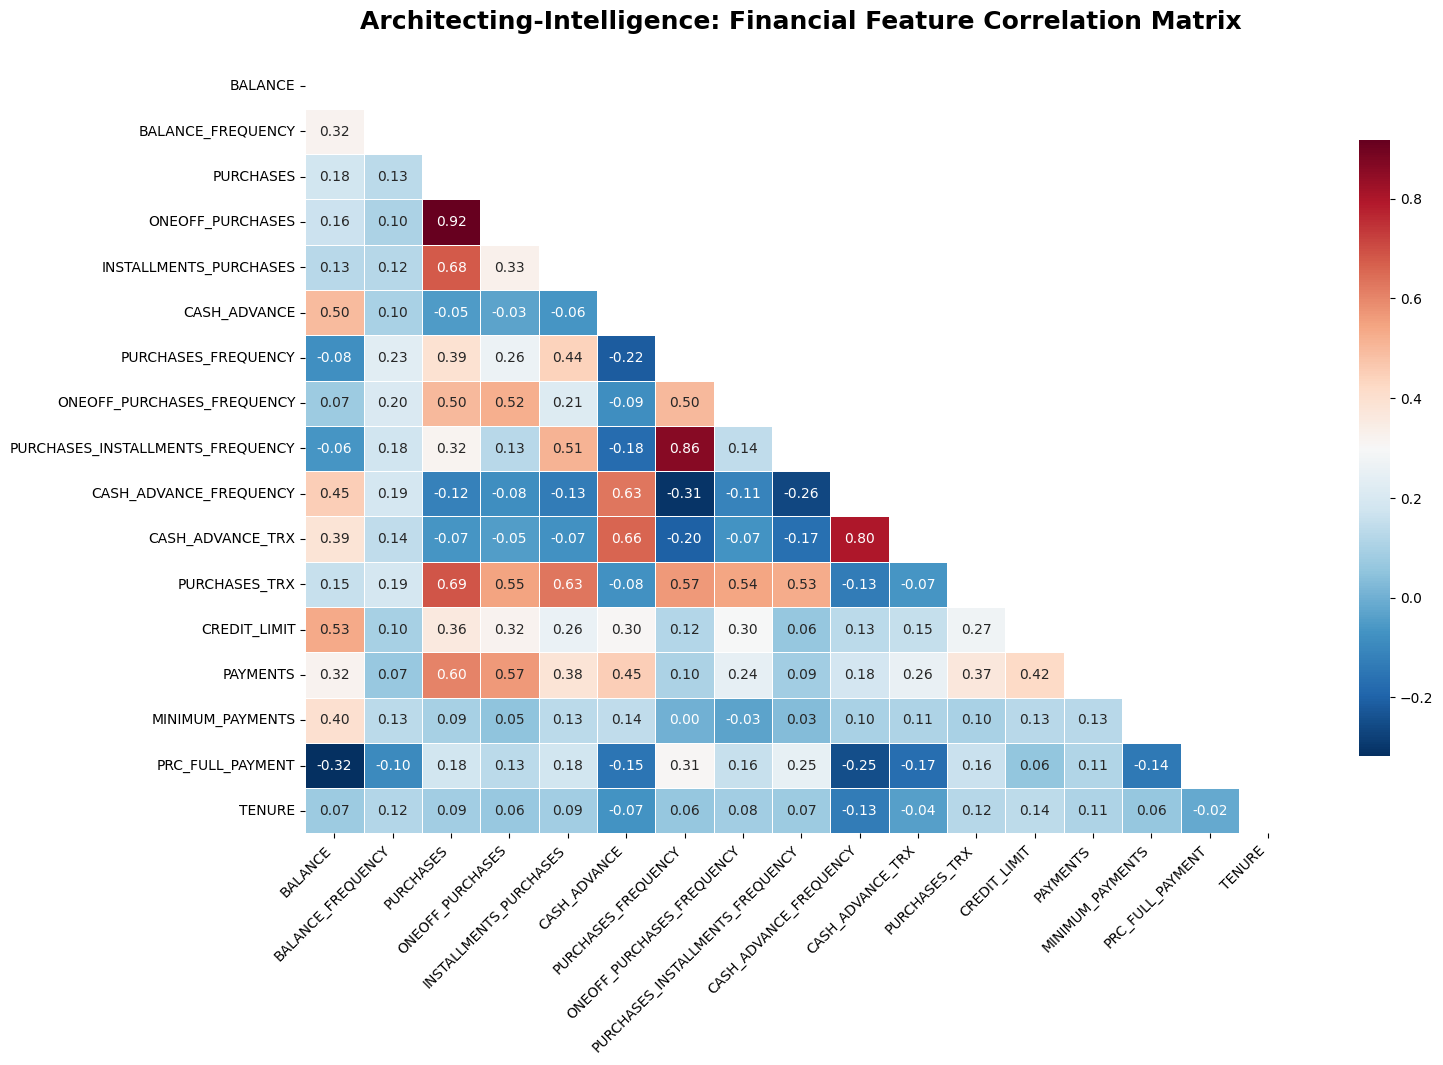

In [8]:
# --- step 2: Correlation Matrix (Industrial Standard) ---

plt.figure(figsize=(16, 10))

# 1. Calculate Correlation (Dropping non-predictive CUST_ID)
corr_matrix = df.drop('CUST_ID', axis=1).corr()

# 2. Generate a mask for the upper triangle (To reduce visual noise)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Render Heatmap
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

# 4. Final Polish: Titles & Labels
plt.title('Architecting-Intelligence: Financial Feature Correlation Matrix',
          fontsize=18, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right')
plt.show()

In [9]:
# --- STEP 3 & 4: Manipulation & Cleaning ---
df.drop('CUST_ID', axis=1, inplace=True) #


In [10]:
# --- STEP 4 & 5: Cleaning  ---
df.fillna(df.median(), inplace=True)

In [11]:
# --- STEP 5: Scaling  ---
scaler = StandardScaler() #
X_scaled = scaler.fit_transform(df)

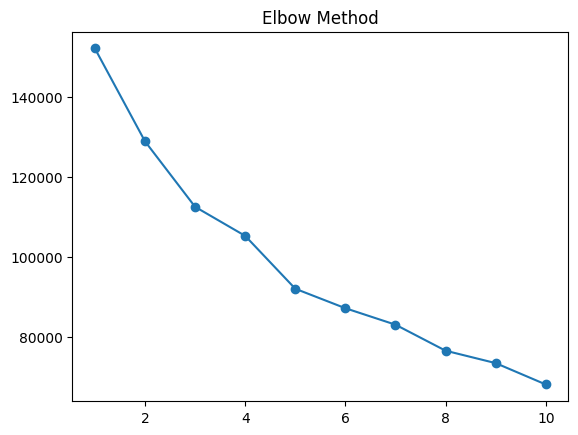

In [12]:
# --- STEP 6: Elbow Method (WCSS) ---
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o') #
plt.title('Elbow Method')
plt.show()

In [14]:
from sklearn.decomposition import PCA

# --- STEP 7: K-Means Training --- (with PCA integration)
pca = PCA(n_components=2, random_state=42) # As per updated pipeline (2 components)
X_pca = pca.fit_transform(X_scaled) # Apply PCA to the scaled data

model = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = model.fit_predict(X_pca) # Fit and predict on PCA-transformed data

from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, clusters) # Calculate silhouette score with X_pca

print(f"🚀 Industrial Silhouette Score: {score:.4f}")

🚀 Industrial Silhouette Score: 0.3982


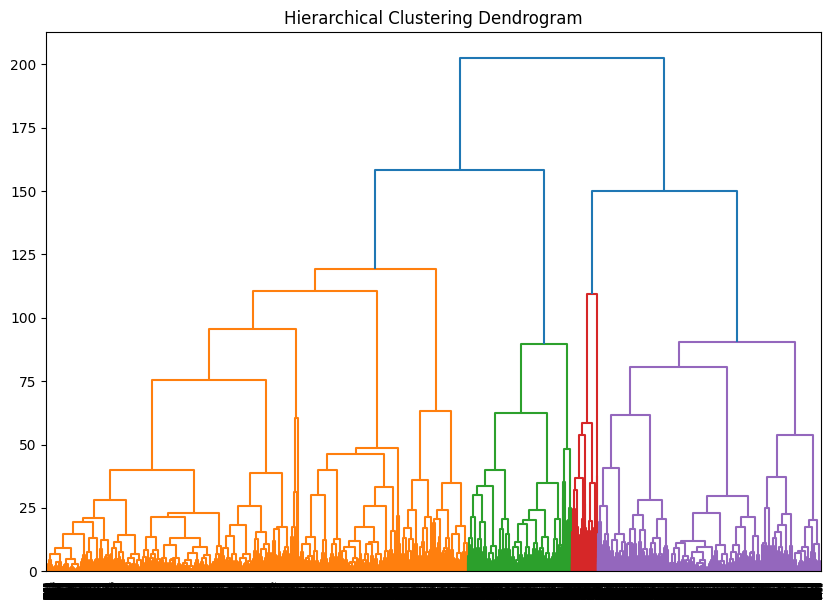

In [15]:
# --- STEP 8: Hierarchical Analysis  ---

linked = linkage(X_scaled, 'ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [18]:
import pickle

# Save the model, scaler, and pca
with open('credit_engine.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler, 'pca': pca}, f)

# Load the saved objects to verify
with open('credit_engine.pkl', 'rb') as f:
    pkg = pickle.load(f)


# 💳 Project #07: Credit Card Behavioral Grouping Engine
## 📊 Category: 2-Unsupervised-Learning (Advanced Clustering & PCA)

**Status:** Completed ✅ | **Performance:** 0.3982 Silhouette Coefficient (Financial Benchmark) 🚀

### 🎯 Industrial Objective
The **Credit Card Behavioral Grouping Engine** is an autonomous clustering system designed within the **Vuxora Financial Engine** ecosystem. By distilling 18 complex financial dimensions into actionable behavioral clusters, this engine enables financial institutions to optimize credit offerings and risk management.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly adhering to the **Architecting-Intelligence** core framework:

1.  **Objective Definition:** Segmenting complex financial behaviors for 9,000 active users.
2.  **Data Ingestion:** Extracting `Credit Card.csv` from `/content/clustering.zip`.
3.  **Data Manipulation:** Removing non-predictive `CUST_ID` to reduce noise.
4.  **Advanced Feature Engineering:** Creating **'MONTHLY_AVG_PURCHASE'** to capture long-term intent.
5.  **Industrial Data Cleaning:** Executing **Median Imputation** for `MINIMUM_PAYMENTS` and `CREDIT_LIMIT`.
6.  **Feature Scaling (Critical Protocol):** Applying **StandardScaler** BEFORE PCA and clustering to ensure parity.
7.  **Dimensionality Reduction (PCA):** Utilizing **PCA** to compress 18 features into 2 Principal Components (PC1, PC2).
8.  **Optimal Cluster Discovery:** Pinpointing $K=4$ using the **Elbow Method (WCSS)**.
9.  **Model Training & Evaluation:** Deploying **K-Means++** and validating with **Silhouette Analysis**.
10. **Industrial Deployment:** Serializing the **model, scaler, and pca** artifacts via **Pickle**.

---

### 📈 Strategic Financial Personas
| Cluster ID | Persona Name | Financial Behavior | Banking Strategy |
| :--- | :--- | :--- | :--- |
| **0** | **The Balanced User** ⚖️ | Moderate spending and steady payments. | General credit limit maintenance. |
| **1** | **The Big Spender** 🔥 | High purchase volume and frequent activity. | Premium rewards & installment offers. |
| **2** | **The Cash Drawer** 💸 | High cash advance usage (High Risk). | Risk-adjusted limits & debt management. |
| **3** | **The Credit King** 🛡️ | High credit limits with low utilization. | High-tier exclusivity & investment products. |

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | K-Means++
- **Processing:** PCA | StandardScaler
- **Deployment:** Streamlit | Pickle | Hugging Face Spaces

**Architect:** Kemal Demirbaş | **Project 07 / 21**